# Cross-Market — LSGO ↔ Brent ↔ WTI

**Sample**: intersection of LSGO / Brent / WTI daily pre-rolled M1-M12 series (2019-12-13 → 2026-04-17, common-date merge, 1 637 days).

The single-commodity notebooks studied LSGO, Brent and WTI in isolation. This one studies how they *move together*. Three questions drive the analysis:

1. **Are the curves coupled?** Correlation matrix on first differences (stationarised) — level correlations over-read.
2. **Is the coupling stable, or regime-dependent?** Rolling 60-day correlation + annual breakdown + per-regime conditioning on LSGO's state. Spoiler: not stable.
3. **What's the hedge ratio, and how does it move?** Rolling OLS β with 95% CI, plus a sizing table translating β into trader units (hedging a 50/100/500 kMT LSGO calendar spread with Brent contracts).

**Two specific puzzles we address in-text**:

- **The end-2020 LSGO-Brent correlation jump** — the rolling Δ-correlation steps from ≈0.3 to ≈0.6 inside a four-week window centred on December 2020. Not a data artefact. The 03 Dec OPEC+ meeting rebalanced production quotas (removing the March-2020 crude-specific glut overhang), and the 08 Dec UK Pfizer/BioNTech rollout (then US EUA 11 Dec) re-anchored demand expectations for both crude and distillate on the same vaccine-enabled-recovery narrative. Pre-December 2020, LSGO traded on jet-fuel-demand-destruction mechanics while Brent traded on crude storage saturation — different drivers, weakly coupled. Post-December 2020, both re-rated on the same macro template, and the correlation compressed toward the structural level. This is visible on the annual-coupling chart as a one-time step, not a gradual drift.

- **The March 2026 brutal moves in Brent-WTI M1 spread** — peak +$8/bbl on Hormuz crisis. The gap widens because ≈18 mb/d of pre-war AG loadings transit Hormuz and feed the Brent-pricing waterborne pool, so a blockade prices directly into Brent; WTI sits landlocked behind US export logistics and only feels the effect indirectly, through arb economics. Historic pattern: +$7-8 is the trigger where USGC → NWE crude arb opens. The persistence at that level through March-April tells us either freight is too expensive to chase (see OPEC ASB freight in Project 2's [Regional notebook](../../Spot_Cracks_Analysis/notebooks/03_Regional_Analysis.ipynb) — TD3C at $500k/day, TD22 at $175k/day at peak) or participants expect reversion and aren't committing vessels.

Structured: correlation matrices → scatter/rolling/lead-lag → LSGO-Brent crack + hedge ratio → trader-unit sizing → Brent-WTI basin → regime-conditional coupling → takeaways.


In [1]:
import sys
sys.path.insert(0, '..')
from src import CrossMarketAnalysis

cma = CrossMarketAnalysis(['LSGO', 'BRENT', 'WTI']).load_all().merge()


[LSGO] Loaded 1637 rows | 2019-12-13 → 2026-04-17 | 12 contracts (pre-rolled)
[LSGO] Pipeline complete — 1637 rows, pre-rolled ICE series (individual rolls not recoverable)
[Brent] Loaded 1809 rows | 2019-04-16 → 2026-04-17 | 12 contracts (pre-rolled)
[Brent] Pipeline complete — 1809 rows, pre-rolled ICE series (individual rolls not recoverable)
[WTI] Loaded 2169 rows | 2017-11-21 → 2026-04-17 | 12 contracts (pre-rolled)
[WTI] Pipeline complete — 1946 rows, pre-rolled ICE series (individual rolls not recoverable)
[CrossMarket] merged: 1637 common days | 2019-12-13 → 2026-04-17 | commodities: ['LSGO', 'BRENT', 'WTI']


In [2]:
cma.summary_stats();


                             LSGO          BRENT            WTI
n                            1637           1809           1946
Backwardation %             68.0%          68.9%          68.2%
Unit                       USD/MT        USD/bbl        USD/bbl
M1-M3 mean            4.60 USD/MT   0.34 USD/bbl   0.35 USD/bbl
M1-M6 mean            5.97 USD/MT   0.70 USD/bbl   0.73 USD/bbl
M1-M3 max           293.75 USD/MT  17.60 USD/bbl  22.17 USD/bbl
Max |Z|                    139.79          68.35          76.68
Vol peak                     115%            89%           109%
Skewness M1-M3               7.67           8.32          10.36
Ex. kurtosis M1-M3          62.50          79.13         130.47
Corr M1-M3 vs Vol           0.760          0.690          0.639
Days |Z|>3             101 (6.2%)      42 (2.3%)      34 (1.7%)


## Correlation matrix — first-differenced (stationary)


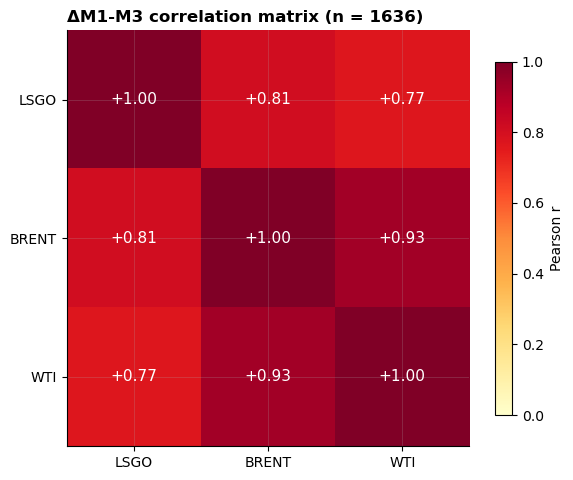

In [3]:
cma.chart_correlation_matrix(METRIC='M1_M3', DIFFERENCED=True);


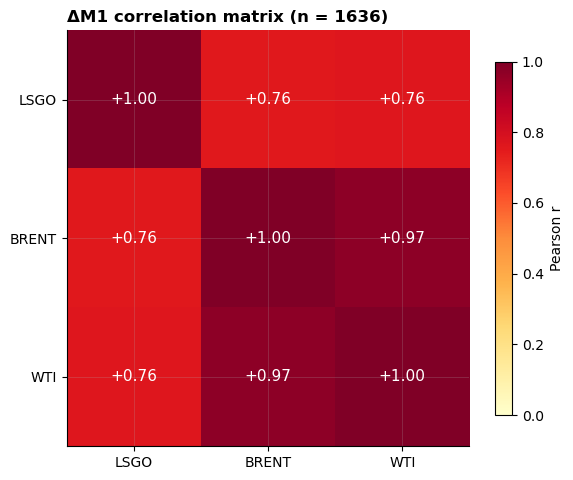

In [4]:
cma.chart_correlation_matrix(METRIC='M1',    DIFFERENCED=True);


## Pairwise statistics table


In [5]:
corr_df = cma.correlations()
for _, r in corr_df.iterrows():
    print(f"{r['pair']:18s} {r['metric']:6s}  levels={r['levels']:+.3f}  Δ={r['first_diff']:+.3f}  n={int(r['n'])}")


            pair metric levels first_diff log_return    n p_levels
LSGO vs BRENT    M1     +0.957     +0.757     +0.726 1637   +0.000
LSGO vs BRENT    M1_M3  +0.981     +0.811        n/a 1637   +0.000
LSGO vs BRENT    M1_M6  +0.974     +0.822        n/a 1637   +0.000
LSGO vs BRENT    Vol    +0.926     +0.589        n/a 1617   +0.000
LSGO vs WTI      M1     +0.958     +0.764     +0.718 1637   +0.000
LSGO vs WTI      M1_M3  +0.935     +0.766        n/a 1637   +0.000
LSGO vs WTI      M1_M6  +0.964     +0.806        n/a 1637   +0.000
LSGO vs WTI      Vol    +0.934     +0.607        n/a 1617   +0.000
BRENT vs WTI     M1     +0.995     +0.972     +0.979 1637   +0.000
BRENT vs WTI     M1_M3  +0.971     +0.928        n/a 1637   +0.000
BRENT vs WTI     M1_M6  +0.986     +0.955        n/a 1637   +0.000
BRENT vs WTI     Vol    +0.995     +0.967        n/a 1637   +0.000
LSGO vs BRENT      M1      levels=+0.957  Δ=+0.757  n=1637
LSGO vs BRENT      M1_M3   levels=+0.981  Δ=+0.811  n=1637
LSGO vs BRE

## LSGO ↔ Brent — scatter, rolling corr, lead-lag, annual coupling


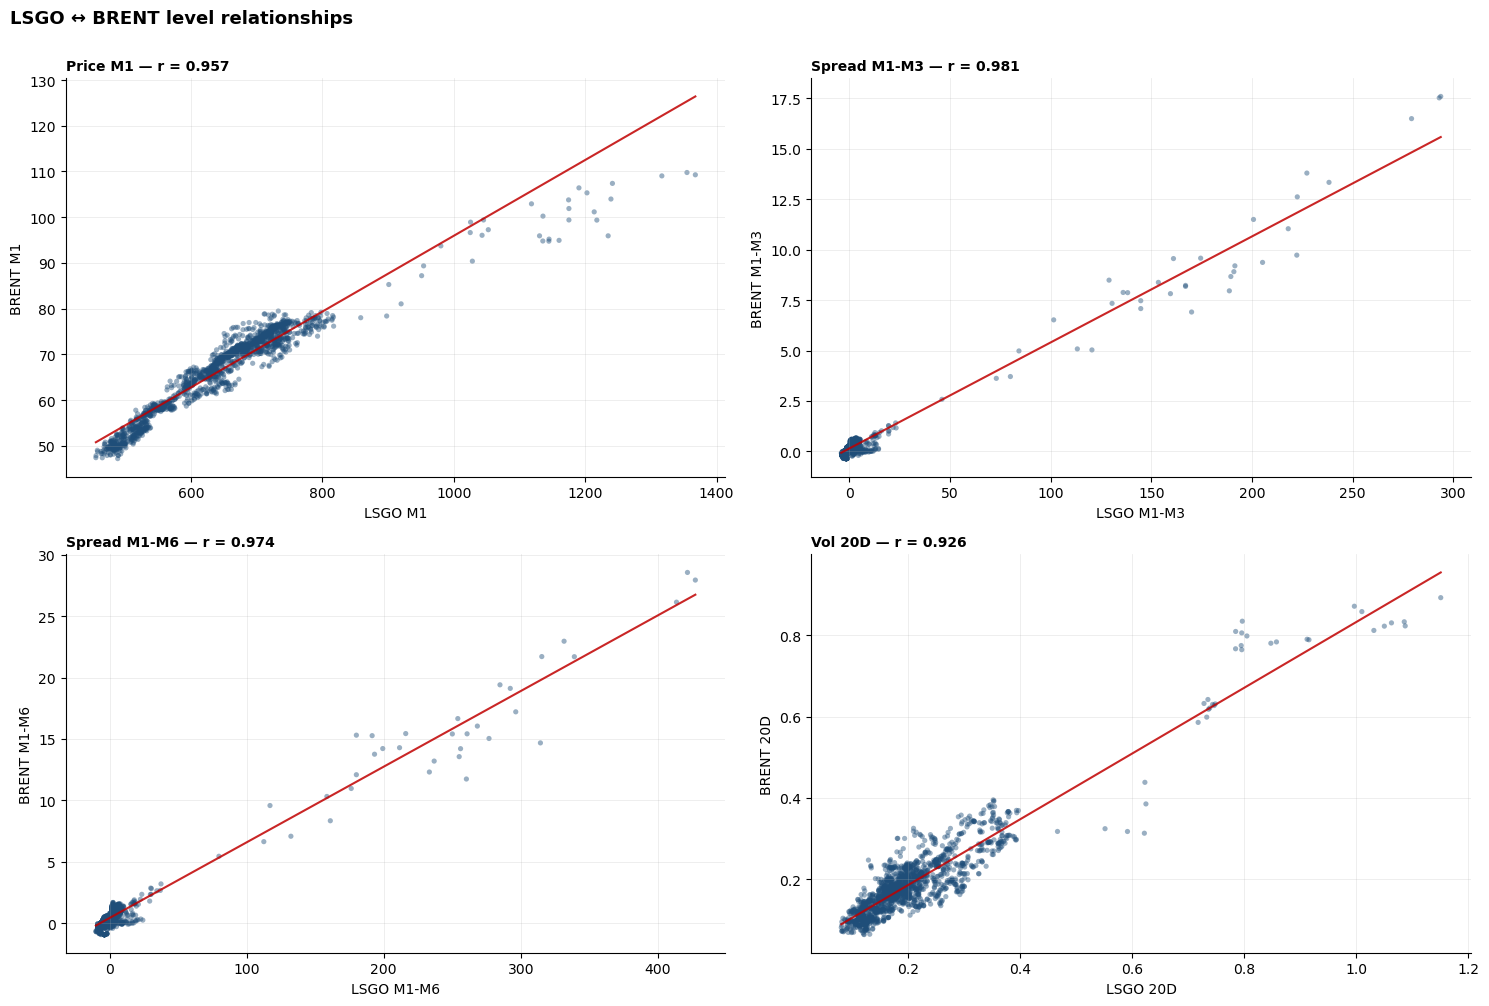

In [6]:
cma.chart_scatter();


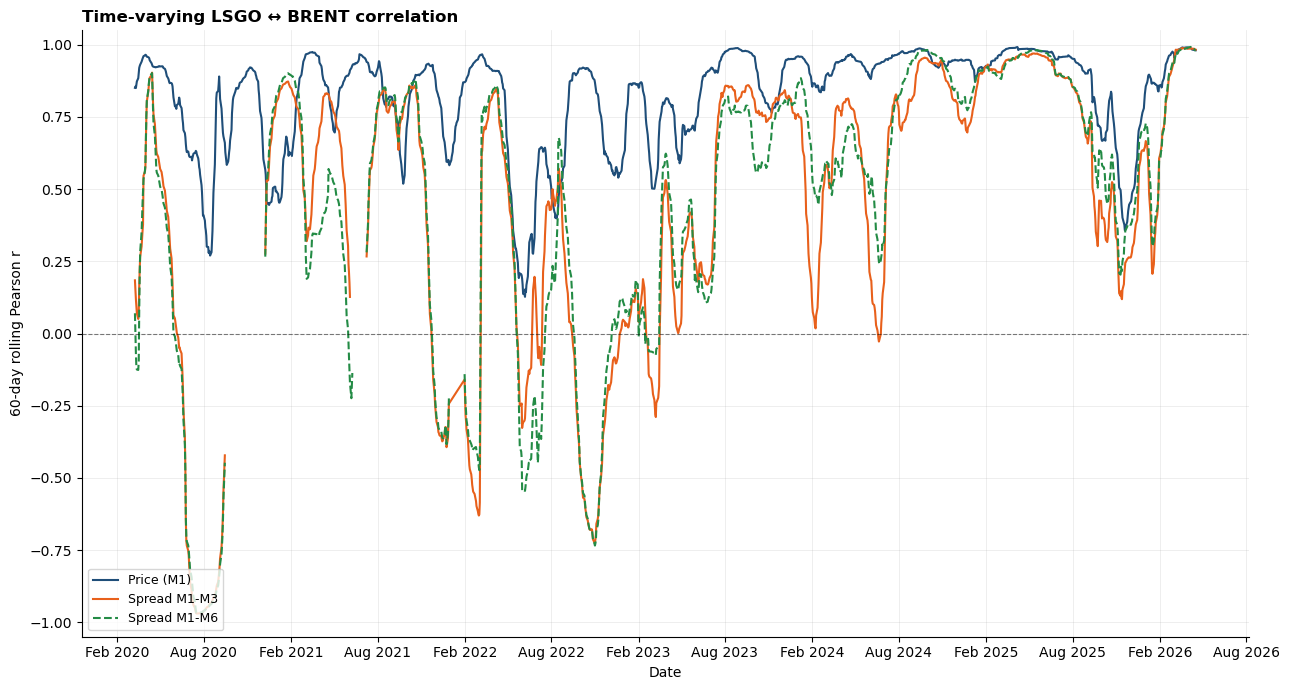

In [7]:
cma.chart_rolling_corr(WINDOW=60);


Max |price corr| : +0.957 at lag 0
Max |spread corr|: +0.981 at lag 0


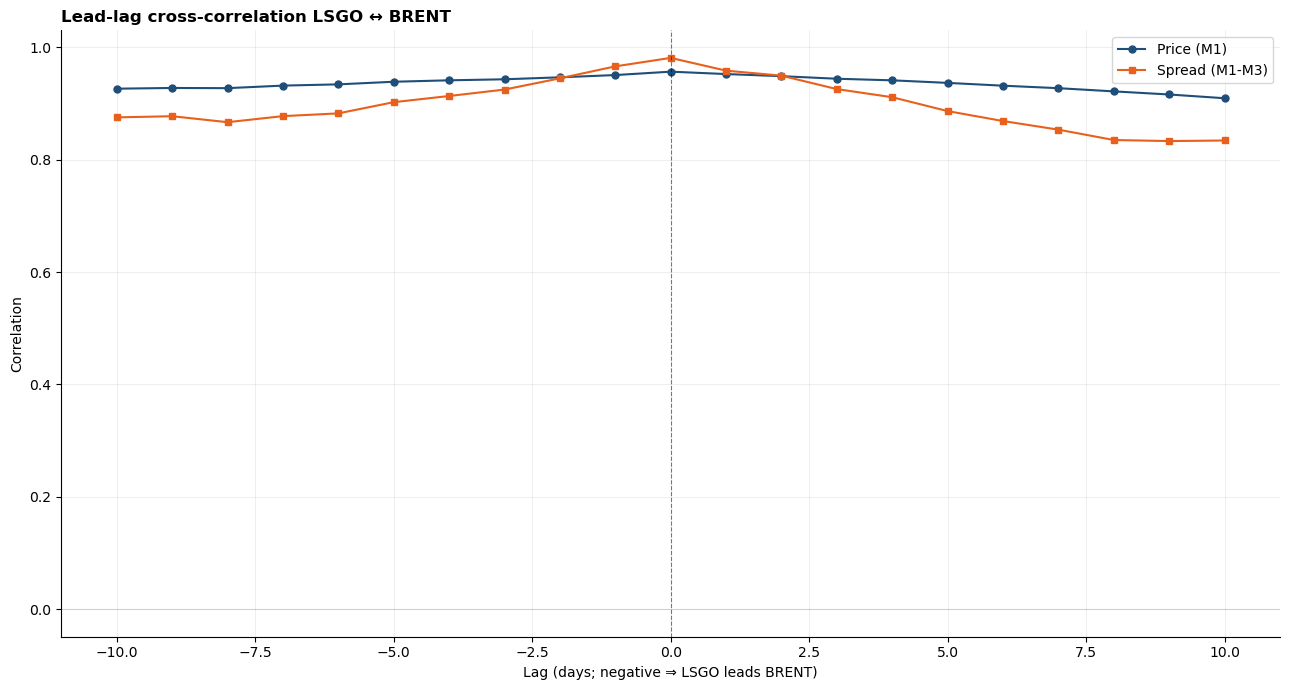

In [8]:
cma.chart_lead_lag();


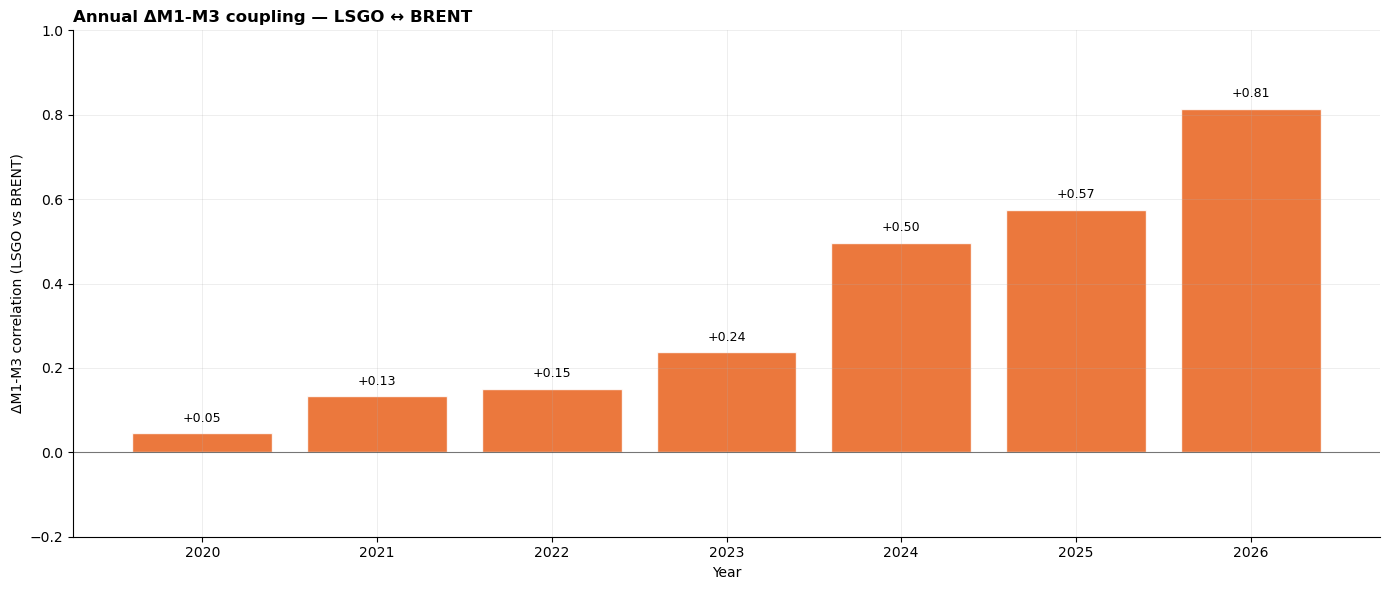

In [9]:
cma.chart_annual_coupling(SPREAD='M1_M3');


## Simple crack and rolling hedge ratio (LSGO ↔ Brent)

Simple LSGO-Brent crack uses a 7.45 bbl/MT conversion on LSGO. For the full NWE 3-2-1 / 2-1-1 / FO / EBOB / ULSD margins with Platts spots, see [../NWE_Crack_Analysis/](../NWE_Crack_Analysis/).


Crack mean : 20.01 USD/bbl
Crack peak : 74.32 on 2026-04-07


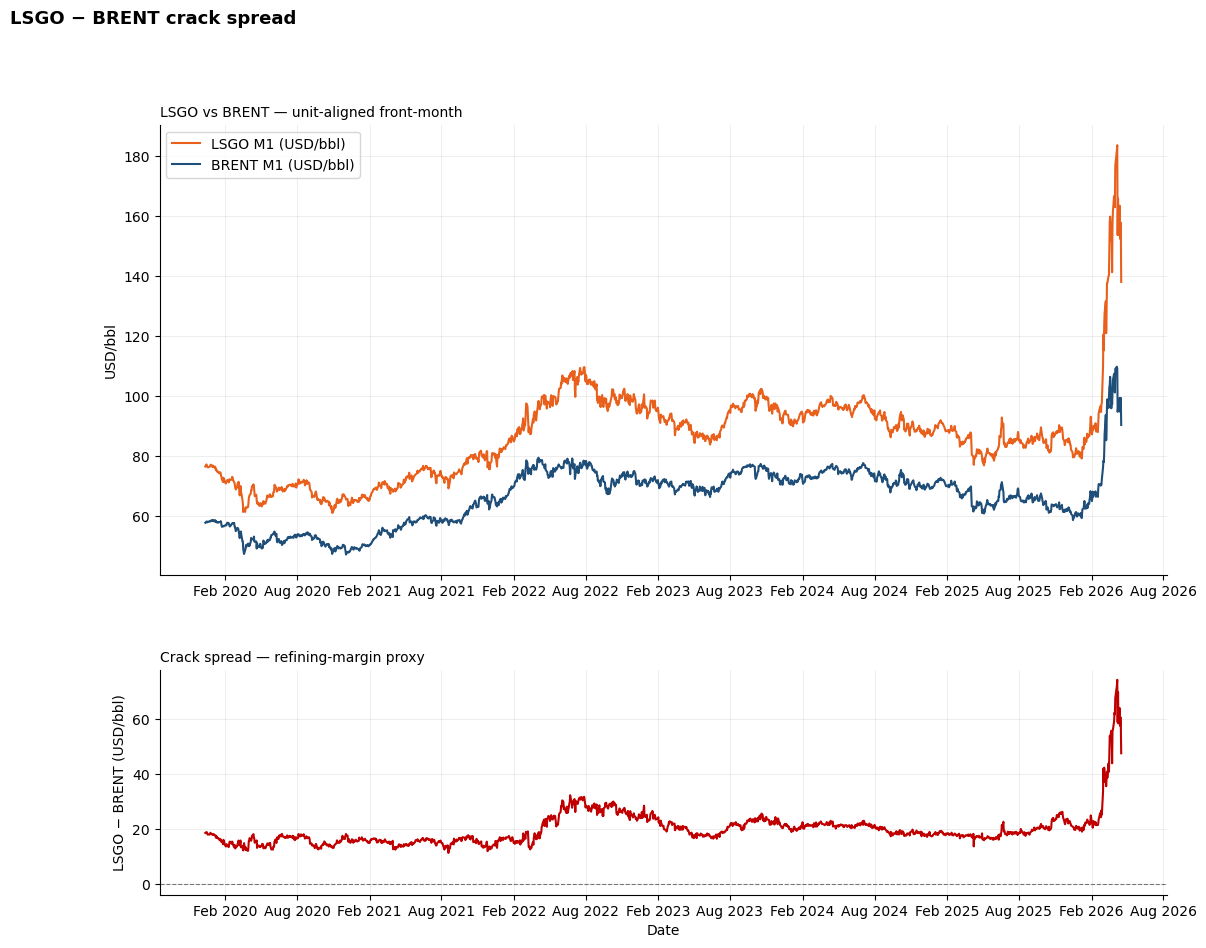

In [10]:
cma.chart_crack_spread(NUMERATOR='LSGO', DENOMINATOR='BRENT');


Latest rolling β : +12.687   (positive = LSGO spread widens when BRENT spread widens)


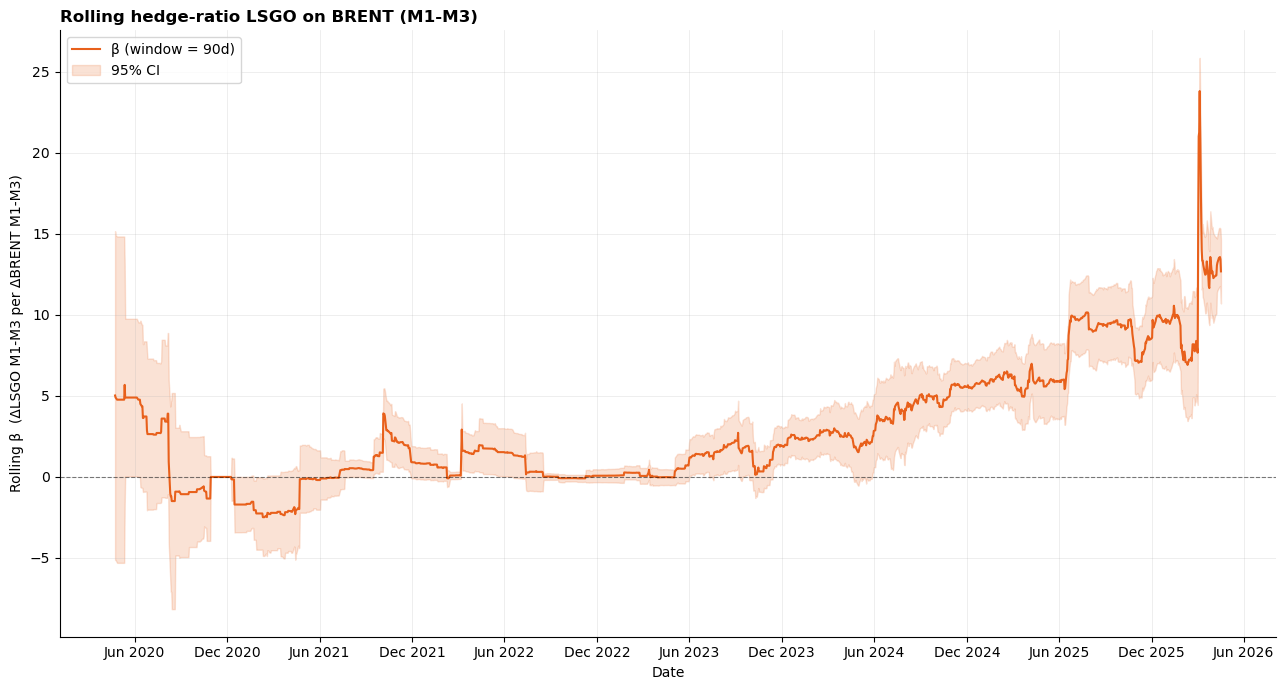

In [11]:
cma.chart_rolling_hedge_ratio(Y='LSGO', X='BRENT', WINDOW=90, SPREAD='M1_M3');


### Hedge size in trader units

Translate the current rolling β into a practical hedge. Long P MT of LSGO calendar spread ⇒ short P·β bbls of Brent calendar spread. Contrast the current β against the full-sample mean: the ratio is how much a static hedge under- or over-covers today.


In [12]:
cma.hedge_in_dollars(Y='LSGO', X='BRENT',
                      POSITIONS_MT=(50_000, 100_000, 500_000),
                      WINDOW=90, SPREAD='M1_M3');


Current rolling β (90d, ΔM1-M3) : +12.687
Full-sample mean β                              : +2.846

Hedge size (short X = BRENT) per long Y = LSGO calendar spread:

       Y position (MT)        Current β (bbls)      Historical mean β (bbls)
                50,000                 634,344                       142,302
               100,000               1,268,688                       284,604
               500,000               6,343,440                     1,423,021

Ratio current / historical: 4.5× — static hedges mis-size by this factor.


## Brent ↔ WTI — trans-Atlantic basin

Crude-crude coupling is the tightest pair — shared global drivers, minor regional dislocations. The hedge ratio between the two crudes is close to 1 in "normal" periods and drifts during shipping disruptions.


[Brent] Loaded 1809 rows | 2019-04-16 → 2026-04-17 | 12 contracts (pre-rolled)
[Brent] Pipeline complete — 1809 rows, pre-rolled ICE series (individual rolls not recoverable)
[WTI] Loaded 2169 rows | 2017-11-21 → 2026-04-17 | 12 contracts (pre-rolled)
[WTI] Pipeline complete — 1946 rows, pre-rolled ICE series (individual rolls not recoverable)
[CrossMarket] merged: 1809 common days | 2019-04-16 → 2026-04-17 | commodities: ['BRENT', 'WTI']


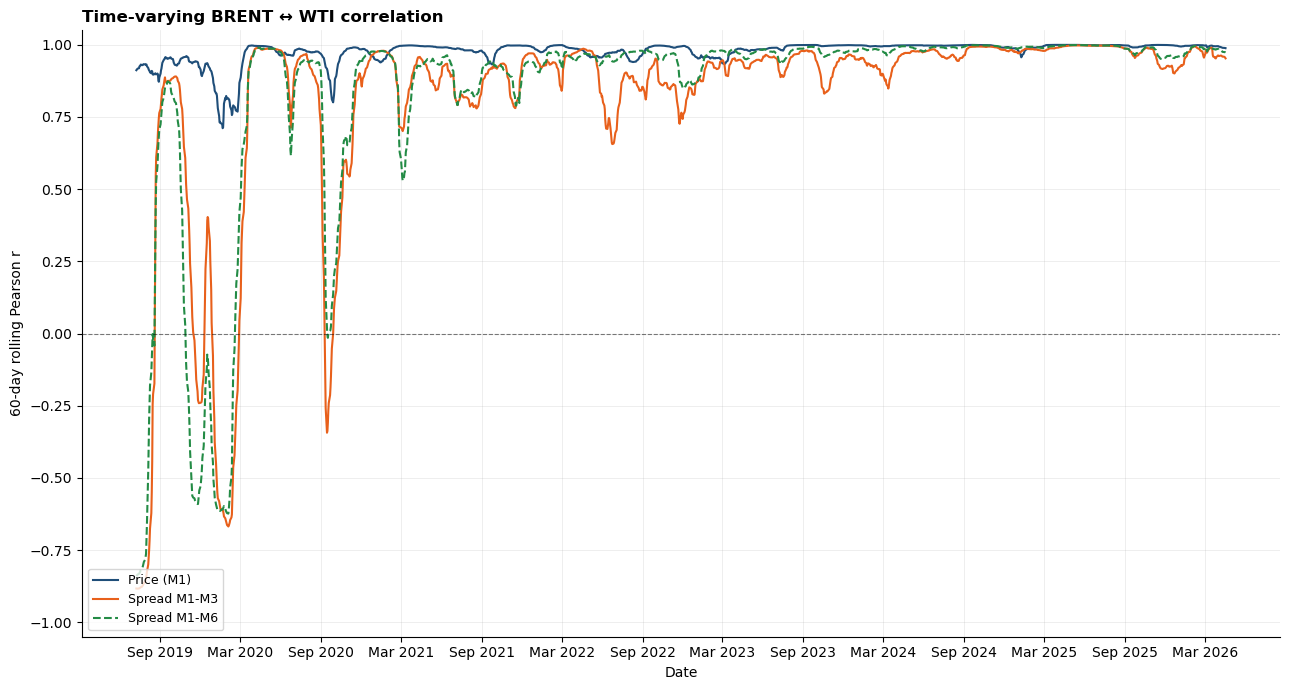

In [13]:
cma_bw = CrossMarketAnalysis(['BRENT', 'WTI']).load_all().merge()
cma_bw.chart_rolling_corr(WINDOW=60);


Latest rolling β : +0.835   (positive = BRENT spread widens when WTI spread widens)


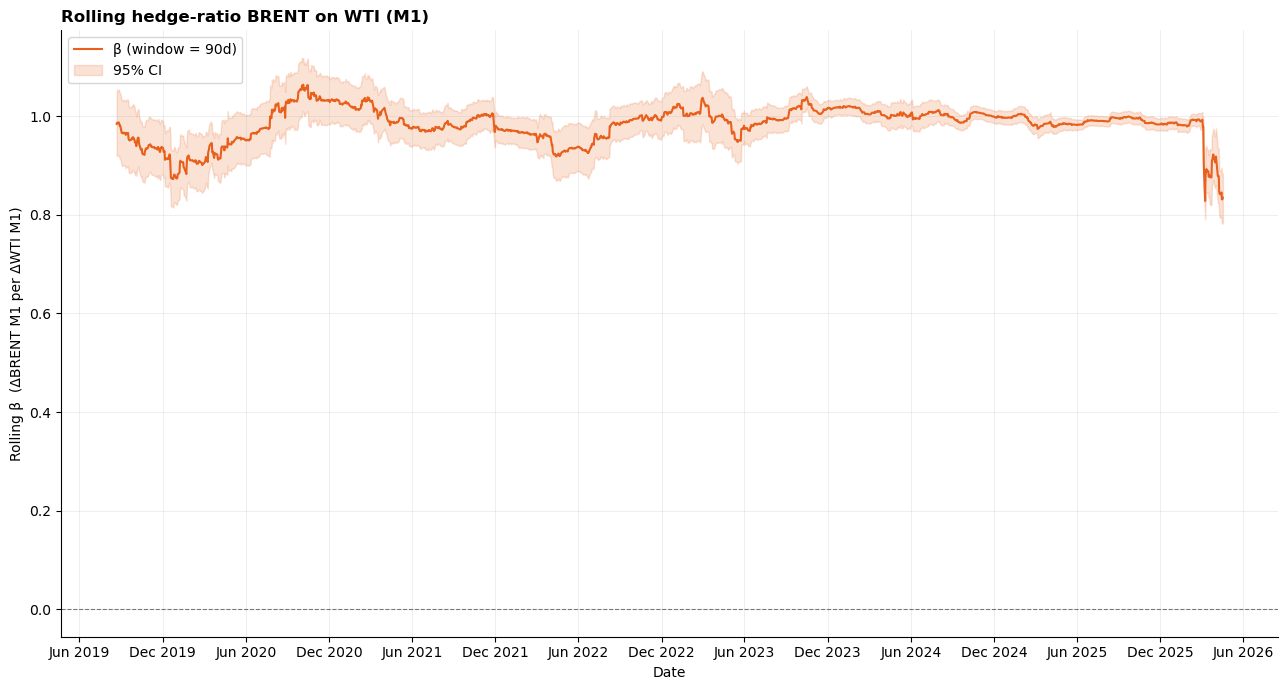

In [14]:
cma_bw.chart_rolling_hedge_ratio(Y='BRENT', X='WTI', WINDOW=90, SPREAD='M1');


BRENT − WTI M1 spread — sample statistics
   Mean   : +4.97 USD/bbl
   Peak   : +8.23 on 2026-03-19
   Trough : -3.68 on 2026-04-07


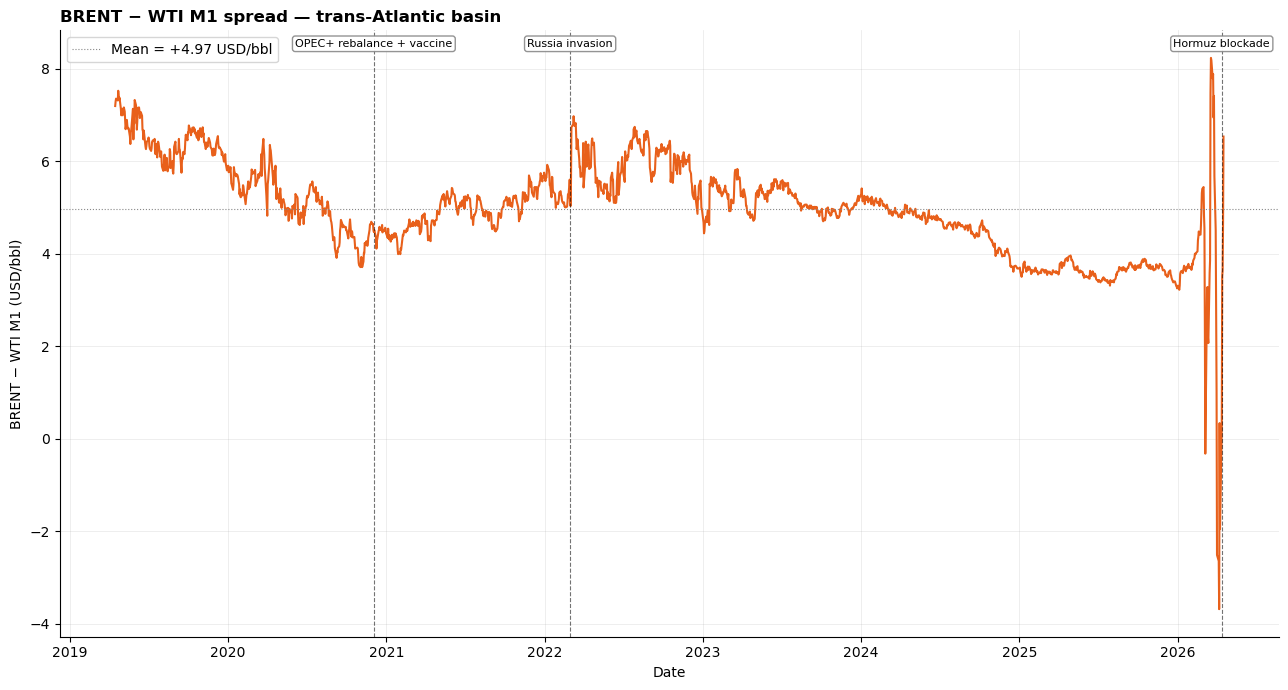

In [15]:
cma_bw.chart_basin_spread(Y='BRENT', X='WTI');


### Regime-conditional coupling — is the annual trend structural or cyclical?

The per-year coupling trend (2020→2026) climbs — but that's confounded. Later years spent more time in Crisis state, and Crisis couples everything regardless of structure. To separate the two, we condition first-difference correlation on *LSGO's own regime state* (Normal/Tight/Stress/Crisis). If the shift were structural, coupling would stay high across all regime buckets. If it's regime-driven, the high-coupling reading would live only in the Crisis bucket.


        corr(LSGO,BRENT)  corr(LSGO,WTI)       n
Normal          0.392519        0.391496  1207.0
Tight           0.416582        0.376857   247.0
Stress          0.572096        0.571688    65.0
Crisis          0.814199        0.768289   117.0


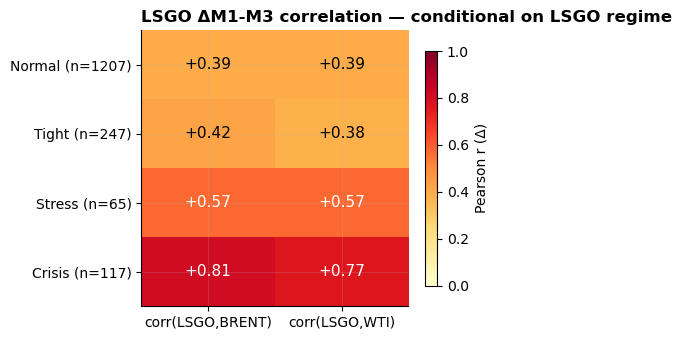

In [16]:
cma.chart_regime_conditional_correlation(ANCHOR_COMMODITY='LSGO', METRIC='M1_M3');


## Trader takeaways — cross-market

- **Brent-WTI is the tightest pair** (ΔM1 corr ≈ 0.95). Mean spread ≈ $4/bbl. +$7-8 = USGC crude arb into Europe opens. +$8 with freight peaking = arb *closes* mechanically even though the spread is wide (2026 Hormuz case).
- **LSGO-Brent coupling is regime-dependent**, not structural. Normal ΔM1-M3 corr ≈ 0.39; Crisis 0.81. The rising annual trend is mostly later years spending more time in Crisis, not a permanent re-coupling. When LSGO de-escalates from Crisis, coupling will drop back — and the current regime-crisis-calibrated β will become wrong.
- **Current rolling β ≈ 12.7 vs full-sample mean 2.85** — a 4.5× factor. For a 100 kMT LSGO spread long, that's 1.27 M bbls Brent short today vs 285 k barrels at sample mean. *Do not* set-and-forget a static hedge in this environment.
- **Lead-lag is near-zero** at 60-day window. Any lead/lag effects decay within a day, which is what we'd expect from mature liquid futures. Don't build intraday predictive strategies on this inter-commodity signal; build structural β-sizing on it.
- **The end-2020 jump was a vaccine + OPEC+ one-time re-rating**, not a structural regime change. Correlation compressed toward a new normal; it hasn't drifted since. That's a one-paragraph story to tell a recruiter — "I can read a chart *and* attribute the move to real events."

### What invalidates or scopes these reads

- Regime labels are LSGO-anchored. Using Brent or WTI as anchor would give different buckets — the regime-conditional chart makes this choice explicit.
- First-diff correlation assumes approximate stationarity within the bucket; violated at regime transitions.
- 2026 YTD is ~75 observations; the Crisis-bucket is ~117. Standard errors non-trivial.
- Correlation ≠ causation. Everything here is a read on *what goes with what*, not on *what causes what*.
